In [1]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
plt.rcParams.update({
    'figure.figsize': (4.8, 2.7), 'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 'small', 'ytick.labelsize': 'small',
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 100,
})

import numpy as np
from pathlib import Path
import os, torch, pickle
from jarvis.utils import tqdm
from hexarena import DATA_DIR, STORE_DIR

FIG_DIR = Path('figures')
os.makedirs(FIG_DIR, exist_ok=True)

rng = np.random.default_rng()

# Load precomputed beliefs

In [3]:
from jarvis.utils import array2tensor

subject = 'viktor'
with open(STORE_DIR/f'{subject}.mean.beliefs.pkl', 'rb') as f:
    saved = array2tensor(pickle.load(f))
n_actions = saved['n_actions']

block_infos = saved['block_infos']
block_ids = [block_id for block_id, block_info in block_infos.items() if block_info['kappa'] in [0.01, 0.2] and block_id in saved['inputs']]
inputs = [saved['inputs'][block_id] for block_id in block_ids]
actions = [saved['actions'][block_id] for block_id in block_ids]

print(f'{len(block_ids)} blocks to analyze')

177 blocks to analyze


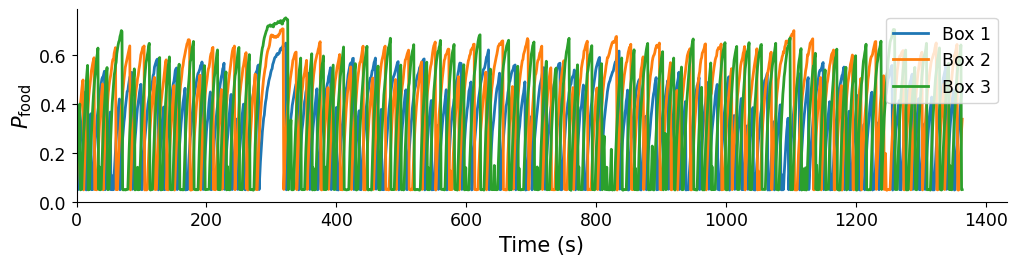

In [4]:
_, ax = plt.subplots(figsize=(12, 2.5))
ax.plot(inputs[4])
ax.set_xlim([0, None])
ax.set_xlabel('Time (s)')
ax.set_ylim([0, None])
ax.set_ylabel(r'$P_\mathrm{food}$')
ax.legend(['Box 1', 'Box 2', 'Box 3'], fontsize='small')
plt.show()

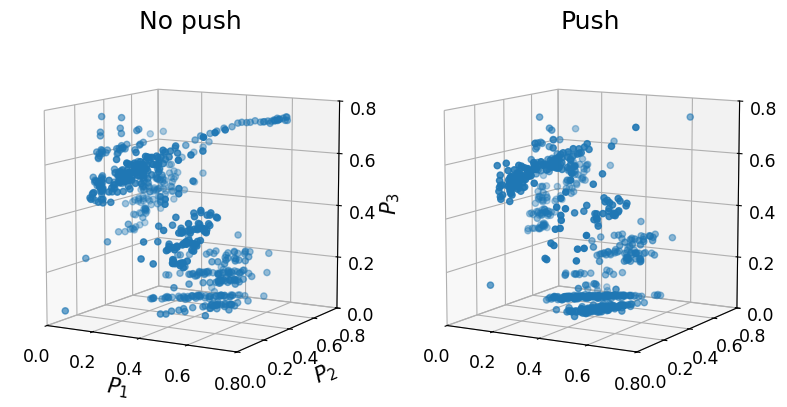

In [5]:
fig = plt.figure(figsize=(8, 4))
for i in range(2):
    ax = fig.add_axes([0.025+i*0.5, 0.05, 0.45, 0.9], projection='3d', elev=10)
    if i==0:
        mask = actions[4]==3
        title = 'No push'
    if i==1:
        mask = actions[4]<3
        title = 'Push'
    vals = inputs[4][mask]
    ax.scatter(vals[:, 0], vals[:, 1], vals[:, 2])
    ax.set_xlim([0, 0.8]), ax.set_ylim([0, 0.8]), ax.set_zlim([0, 0.8])
    ax.set_aspect('equal')
    ax.set_title(title)
    if i==0:
        ax.set_xlabel('$P_1$'), ax.set_ylabel('$P_2$'), ax.set_zlabel('$P_3$')
plt.show()

# Create a HMM policy

In [6]:
from irc.hmp import HiddenMarkovPolicy

n_policies = 3
hmp = HiddenMarkovPolicy(
    n_policies, 3, n_actions, policy={'num_features': [16]},
)

hmp.logits_A.data += torch.eye(n_policies)*5

In [7]:
losses, states, best_epoch = hmp.learn(
    inputs, actions, l2_reg=0.01, jsd_reg=20., switch_reg=20.,
    max_steps=600, n_epochs=2000,
)

  0%|                                                                                                         …

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [16]:
gammas, trajectories = [], []
for i in tqdm(range(len(block_ids)), unit='block'):
    with torch.no_grad():
        _, _, log_pes, _, _, log_gammas, *_ = hmp.baum_welch(inputs[i], actions[i])
    gammas.append(log_gammas.exp().numpy())
    trajectories.append(hmp.viterbi_trajectory(log_pes))

with open(STORE_DIR/f'{subject}.{n_policies}policy.labels.pkl', 'wb') as f:
    pickle.dump({
        'block_ids': block_ids,
        'block_infos': block_infos,
        'beliefs': [inputs[i].numpy() for i in range(len(block_ids))],
        'actions': [actions[i].numpy() for i in range(len(block_ids))],
        'gammas': gammas,
        'labels': trajectories,
    }, f)

torch.save(hmp.state_dict(), STORE_DIR/f'{subject}.hmp{n_policies}.state.pt')

  0%|                                                                                                         …

In [8]:
b_idx = rng.choice(len(block_ids))
# i = 4
with torch.no_grad():
    logits, log_pas, log_pes, log_alphas, log_betas, log_gammas, log_xis, log_Z = hmp.baum_welch(inputs[b_idx], actions[b_idx])

In [9]:
torch.logsumexp(log_xis, dim=0)

tensor([[ 5.5920,  3.9835, -3.9832],
        [ 0.1970,  6.0374,  3.9875],
        [ 3.9615,  0.3503,  5.8467]])

In [10]:
log_count = torch.logsumexp(log_xis, dim=0)
log_count.exp()

tensor([[2.6827e+02, 5.3704e+01, 1.8626e-02],
        [1.2177e+00, 4.1880e+02, 5.3923e+01],
        [5.2538e+01, 1.4195e+00, 3.4611e+02]])

In [11]:
log_stay = torch.diag(log_count).min()-torch.logsumexp(log_count, dim=(0, 1))
print(log_stay.exp())
torch.log(1/n_policies-log_stay.exp())

tensor(0.2243)


tensor(-2.2162)

In [12]:
hmp.log_A.exp()

tensor([[9.7639e-01, 2.3591e-02, 1.5011e-05],
        [2.3384e-06, 9.9471e-01, 5.2905e-03],
        [3.1383e-04, 2.3450e-07, 9.9969e-01]], grad_fn=<ExpBackward0>)

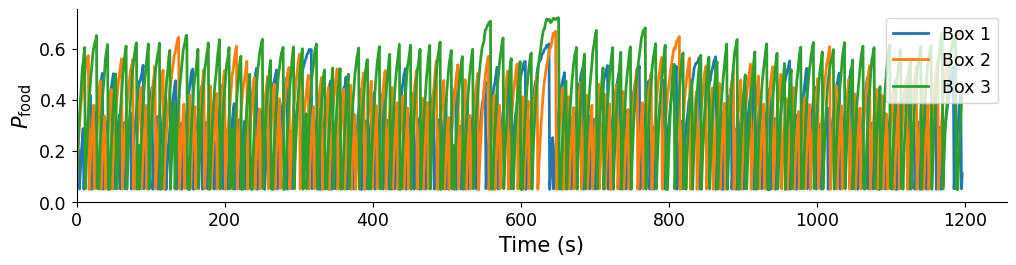

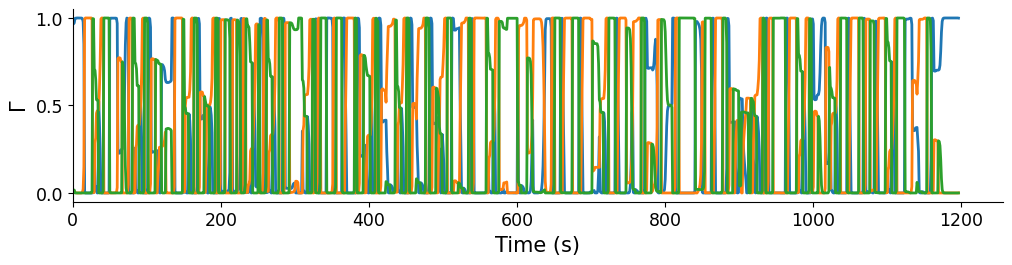

In [13]:
_, ax = plt.subplots(figsize=(12, 2.5))
ax.plot(inputs[b_idx])
ax.set_xlim([0, None])
ax.set_xlabel('Time (s)')
ax.set_ylim([0, None])
ax.set_ylabel(r'$P_\mathrm{food}$')
ax.legend(['Box 1', 'Box 2', 'Box 3'], fontsize='small')
plt.show()

gammas = log_gammas.exp()
_, ax = plt.subplots(figsize=(12, 2.5))
ax.plot(gammas)
ax.set_xlim([0, None])
ax.set_xlabel('Time (s)')
ax.set_yticks([0, 0.5, 1])
ax.set_ylabel(r'$\Gamma$')
plt.show()

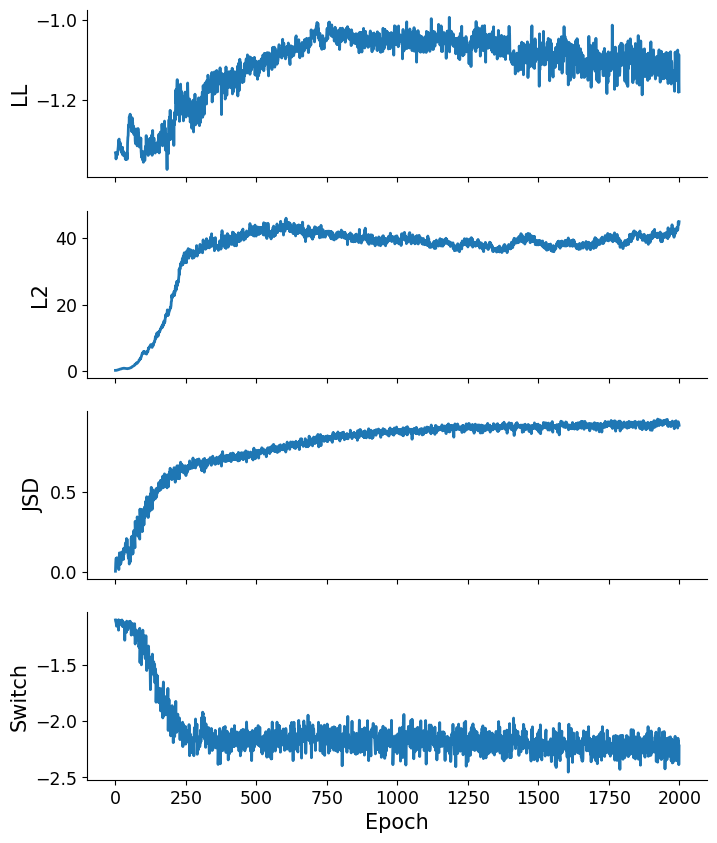

In [14]:
_, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)
ylabels = ['LL', 'L2', 'JSD', 'Switch']
for i, ax in enumerate(axes):
    ax.plot(losses[:, i])
    ax.set_ylabel(ylabels[i])
axes[-1].set_xlabel('Epoch')
plt.show()

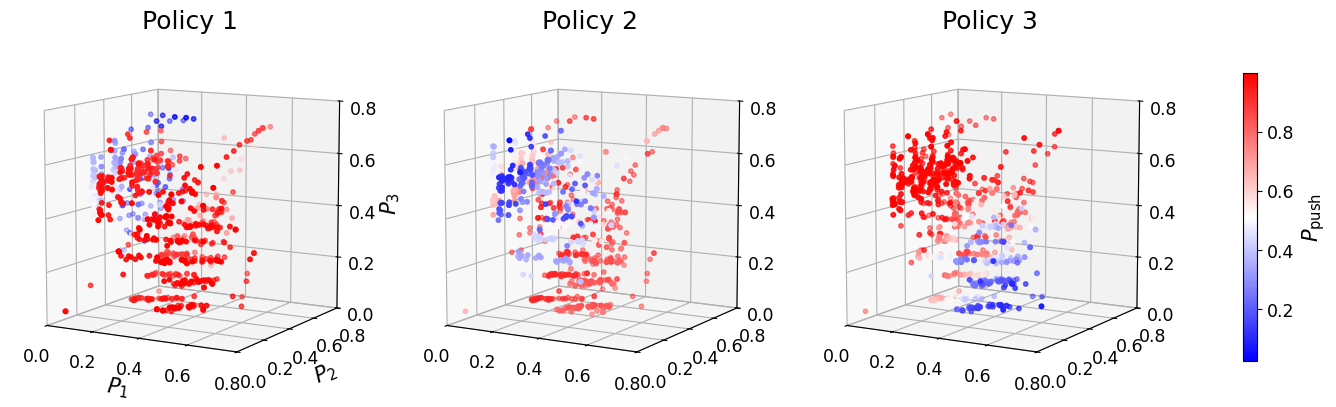

In [15]:
# beliefs = torch.cat(inputs)
beliefs = inputs[b_idx]
probs = []
for i in range(n_policies):
    with torch.no_grad():
        logits = hmp.policies[i](beliefs)
        probs.append(1-torch.softmax(logits, dim=1)[:, 3])
        # probs.append(torch.softmax(logits, dim=1)[:, 0])
probs = torch.stack(probs)

fig = plt.figure(figsize=(n_policies*5, 4))
axes = []
for i in range(n_policies):
    ax = fig.add_axes([0.025+i/n_policies, 0.05, 0.9/n_policies, 0.9], projection='3d', elev=10)
    axes.append(ax)
    idxs = rng.choice(len(beliefs), 1000)
    h = ax.scatter(
        beliefs[idxs, 0], beliefs[idxs, 1], beliefs[idxs, 2], s=10,
        c=probs[i, idxs], cmap='bwr', vmin=probs.min(), vmax=probs.max(),
    )
    ax.set_xlim([0, 0.8]), ax.set_ylim([0, 0.8]), ax.set_zlim([0, 0.8])
    ax.set_aspect('equal')
    ax.set_title(f'Policy {i+1}')
    if i==0:
        ax.set_xlabel('$P_1$'), ax.set_ylabel('$P_2$'), ax.set_zlabel('$P_3$')
fig.colorbar(h, ax=axes, shrink=0.8, label=r'$P_\mathrm{push}$')
plt.show()